## Loading dataset

In [10]:
from MLtools import ImageData
from torch.utils.data import DataLoader

image_folder = "resized_fruits/0"
xml_path = "annotations.xml"

train_data = ImageData(image_folder, xml_path)

In [11]:
image, mask = train_data[0]

In [3]:
image.shape

(3, 640, 640)

In [4]:
mask.shape

(640, 640)

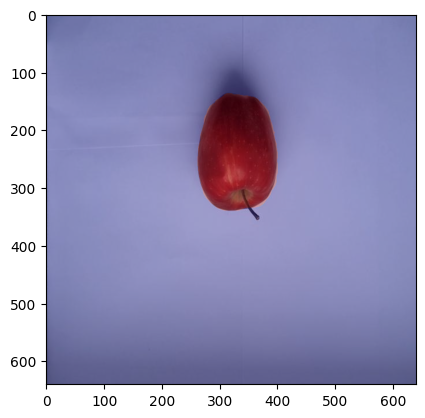

In [5]:
ImageData.draw_appled_mask(image, mask)

In [12]:
BS = 2
train_loader = DataLoader(train_data, batch_size=BS, shuffle=False)

## Appling model

In [8]:
from MLtools import SC_Model
from torchsummary import summary
import torch

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model = SC_Model().to(device)
print(device)

train_losses = []
val_losses   = []

summary(model, (3,256,256))

cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
       BatchNorm2d-2         [-1, 64, 256, 256]             128
         LeakyReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
         LeakyReLU-6         [-1, 64, 256, 256]               0
         MaxPool2d-7         [-1, 64, 128, 128]               0
         Dropout2d-8         [-1, 64, 128, 128]               0
            Conv2d-9        [-1, 128, 128, 128]          73,856
      BatchNorm2d-10        [-1, 128, 128, 128]             256
        LeakyReLU-11        [-1, 128, 128, 128]               0
           Conv2d-12        [-1, 128, 128, 128]         147,584
      BatchNorm2d-13        [-1, 128, 128, 128]             256
        LeakyReLU-14        [-1, 12

In [19]:
batch, target = next(iter(train_loader))

with torch.no_grad():
    output = model(batch.float())

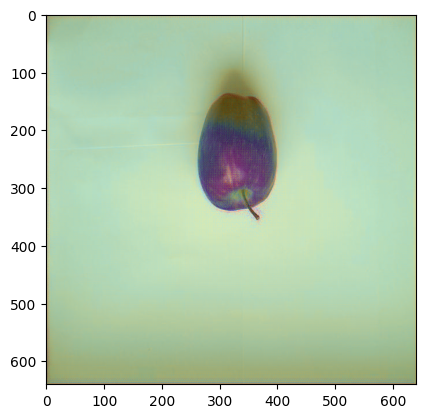

In [26]:
ImageData.draw_appled_mask(batch[0], output[0,0])

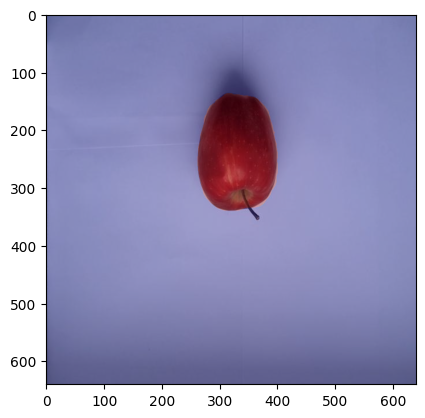

In [28]:
ImageData.draw_appled_mask(batch[0], target[0])